In [59]:
from sympy import Eq, symbols, Function, solve

x, y, t, dt, dx, dy = symbols('x, y, t, dt, dx, dy')
C1, C2 = symbols('C1, C2')
u = Function('u')(t, x, y)

In [60]:
continuous = Eq(u.diff(t) + C1*u.diff(x) + C2*u.diff(y), 0)
continuous

Eq(C1*Derivative(u(t, x, y), x) + C2*Derivative(u(t, x, y), y) + Derivative(u(t, x, y), t), 0)

In [61]:
u = symbols('u', cls=Function)
discrete = Eq((u(t+1, x, y)-u(t, x, y))/dt + ((u(t, x-1, y)-u(t, x, y))/dx) + ((u(t, x, y-1)-u(t, x, y))/dy), 0)
discrete

Eq((-u(t, x, y) + u(t, x, y - 1))/dy + (-u(t, x, y) + u(t, x - 1, y))/dx + (-u(t, x, y) + u(t + 1, x, y))/dt, 0)

In [62]:
solution = Eq(solve(discrete, u(t+1, x, y))[0], u(t+1, x, y))
solution

Eq((dt*dx*(u(t, x, y) - u(t, x, y - 1)) + dt*dy*(u(t, x, y) - u(t, x - 1, y)) + dx*dy*u(t, x, y))/(dx*dy), u(t + 1, x, y))

In [66]:
import numpy as np
import matplotlib.pyplot as plt

width = 20
height = 20
nu = width*height

dx = 1
dy = 1
dt = 0.025
nt = 50

u = np.ones(shape=(width, height))
u[int(width/4):int(3*(width/4))] = 2

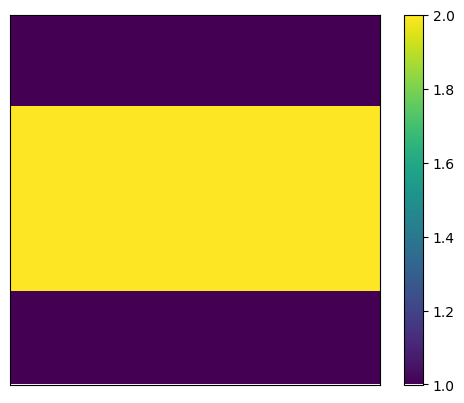

In [67]:
def plot(u):
    plt.imshow(u)
    plt.yticks([])
    plt.xticks([])
    plt.grid(which="minor", color='r', linestyle='-', linewidth=2)
    plt.colorbar()
plot(u)

$\displaystyle \frac{dt dx \left(u{\left(t,x,y \right)} - u{\left(t,x,y - 1 \right)}\right) + dt dy \left(u{\left(t,x,y \right)} - u{\left(t,x - 1,y \right)}\right) + dx dy u{\left(t,x,y \right)}}{dx dy} = u{\left(t + 1,x,y \right)}$

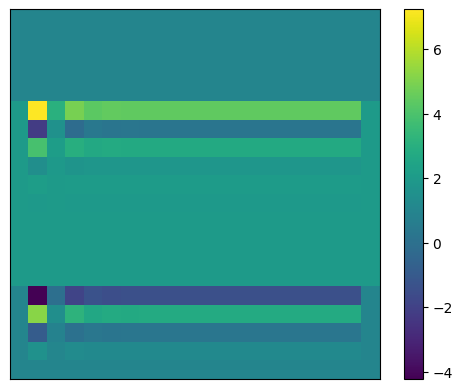

In [68]:
for n in range(nt):
    un = u.copy()
    for x in range(1, width-1):
        for y in range(1, height-1):
            u[x][y] = (dt*dx*(un[x][y] - un[x][y-1]) + dt*dy*(un[x][y] - un[x-1][y]) + dx*dy*un[x][y]) / dx*dy
plot(u)